Title: capacity_data_onshore.ipynb

Purpose: Transform the xml capacity data into some gridded format

Author: Onno Nennecke on 10.02.2025 Modified: 18.06.2025

Input data: 

- Wind energy units from the MaStR
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml

Output data:

- wind_onshore_ic.nc and wind_onshore_height_weighted.nc
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data

In [ ]:
# Import necessary libraries
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Import custom functions
import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()

Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'Lage', 'NameWindpark', 'Nabenhoehe', 'Rotordurchmesser', 
  'Seelage', 'ClusterNordsee', 'Wassertiefe', 'Kuestenentfernung', 'ClusterOstsee', 'Laengengrad',
  'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Gemeinde', 'Gemeindeschluessel', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart', 'EegMaStRNummer',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 
       'DatumEndgueltigeStilllegung', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'HausnummerNichtGefunden',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer','Hersteller', 'Technologie', 'Typenbezeichnung',
       'Rotorblattenteisungssystem', 'AuflageAbschaltungLeistungsbegrenzung',
       'AuflagenAbschaltungSchallimmissionsschutzNachts',
       'AuflagenAbschaltungSchallimmissionsschutzTagsueber',
       'AuflagenAbschaltungSchattenwurf', 'AuflagenAbschaltungTierschutz',
       'AuflagenAbschaltungEiswurf', 'AuflagenAbschaltungSonstige',
       'Nachtkennzeichnung','Hausnummer']

In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Postleitzahl': einheit.find('Postleitzahl').text if einheit.find('Postleitzahl') is not None else np.nan,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
# print(df)

In [4]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb

# Drop off-shore units
df_2 = df_1[df_1['Lage'] != 889].copy()

# Drop columns EinheitBetriebsstatus and Lage as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Lage'], inplace=True)

6689


In [5]:
# Manually fill in missing postal codes
df_2[df_2['Postleitzahl'].isna()]

plz_mapping = {
    'SEE936808217954': '06406',
    'SEE968754227626': '49762',
    'SEE955273809822': '49762',
    'SEE948208029693': '54675'
}

df_2['Postleitzahl'] = df_2.apply(
    lambda row: plz_mapping[row['EinheitMastrNummer']] if pd.isna(row['Postleitzahl']) and row['EinheitMastrNummer'] in plz_mapping else row['Postleitzahl'],
    axis=1
)

In [6]:
# Some data inspection

df_2['Nabenhoehe'].describe()

# df_2['Rotordurchmesser'].describe()

# df_2['Bruttoleistung'].describe()

# df_2['Nettonennleistung'].describe()

count    29038.000000
mean        98.613275
std         35.038866
min          1.000000
25%         70.000000
50%         98.350000
75%        135.000000
max        173.480000
Name: Nabenhoehe, dtype: float64

In [7]:
# # Count the number of NaN values in the 'column_name' column
# nan_count_plz = df_2['Postleitzahl'].isna().sum()
# print(f"Count of NaN values in 'Postleitzahl': {nan_count_plz}")

# nan_count_co = df_2['Breitengrad'].isna().sum()
# print(f"Count of NaN values in 'Breitengrad': {nan_count_co}")

# # But cancel each other out:
# print(len(df_2[df_2['Breitengrad'].notna() | df_2['Postleitzahl'].notna()]))
# print(len(df_2[df_2['Breitengrad'].isna() & df_2['Postleitzahl'].isna()]))

In [8]:
# Create centroids
# Lade eine Shapefile mit PLZ-Geometrien (z.B. aus OpenStreetMap oder von Statistikbehörden)
plz_shp = gpd.read_file("/climca/people/onennecke/PLZ_Germany/OSM_PLZ.shp")

# Daten mit PLZ-Zentroiden verknüpfen
plz_shp["geometry"] = plz_shp.geometry.centroid

# Reproject data
gdf_latlong = plz_shp.to_crs(epsg=4326)

# print(gdf_latlong.crs)

gdf_latlong['x'] = gdf_latlong['geometry'].x
gdf_latlong['y'] = gdf_latlong['geometry'].y
gdf_latlong

plz_df = gdf_latlong[["plz", "geometry", "x", "y"]]
# plz_df

In [9]:
# list_plz_nd = set(df_2["Postleitzahl"]) - set(plz_df["plz"])    # These PLZs are not in the PLZ shapefile

# print('There are', len(set(df_2["Postleitzahl"])), 'unique plz in the dataset. \n', 
#     'There are', len(set(plz_df["plz"])), 'PLZs in the reference PLZ shapefile. \n',
#     len(list_plz_nd), 'of the plzs in the dataset are not in the PLZ shapefile --> Outdated \n',
#     'These are:', list_plz_nd, '\n',
#     'These', len(list_plz_nd), 'plzs occur', len(df_2[df_2['Postleitzahl'].isin(list_plz_nd)]), 'times in the dataset. \n',
#     'There are', len(set(plz_df["plz"]) - set(df_2["Postleitzahl"])), 'PLZs in the PLZ shapefile but not in the dataset. \n')

In [10]:
# Group by PLZ
grouped = df_2.groupby('Postleitzahl').agg({'Bruttoleistung': 'sum', 'Nettonennleistung': 'sum', 'Nabenhoehe':'mean', 'Rotordurchmesser':'mean'}).reset_index()
# grouped

In [11]:
# Merge the two DataFrames
merged_df = pd.merge(grouped, plz_df, left_on='Postleitzahl', right_on='plz')

merged_df = gpd.GeoDataFrame(merged_df, geometry=merged_df.geometry)
merged_df.drop(columns=['plz'], inplace=True)
# type(merged_df)
# merged_df

In [12]:
# Save current data for further use
# merged_df.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_plz.shp')

In [13]:
# Create a grid
grid = grid_func.create_ref_grid('wind_on_cap')
# grid

In [14]:
# Extract lat/lon center coordinates from the xarray grid (assumed 1D)
lat_vals = grid['lat'].values  # shape (N,)
lon_vals = grid['lon'].values  # shape (M,)

# Create 2D meshgrid of all (lat, lon) combinations
lat_mesh, lon_mesh = np.meshgrid(lat_vals, lon_vals, indexing='ij')  # shape (N, M)

# Flatten meshgrid into a (N*M, 2) array of grid point coordinates
grid_points = np.column_stack((lat_mesh.ravel(), lon_mesh.ravel()))

# Build KDTree for fast nearest neighbor search
tree = cKDTree(grid_points)

# Extract coordinates from GeoDataFrame into a (n_points, 2) array
data_points = np.column_stack((merged_df["y"].values, merged_df["x"].values))

# Query KDTree to find nearest grid point for each data point
distances, flat_indices = tree.query(data_points)  # returns (distance, index)

# Convert flat index to 2D grid indices (lat_idx, lon_idx)
merged_df["lat_idx"], merged_df["lon_idx"] = np.unravel_index(flat_indices, lat_mesh.shape)  # shape (n_points,)

merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,Nabenhoehe,Rotordurchmesser,geometry,x,y,lat_idx,lon_idx
0,01454,6400.0,6400.0,73.000000,54.800000,POINT (13.91345 51.14013),13.913446,51.140132,4,8
1,01561,1.0,1.0,7.200000,2.700000,POINT (13.63389 51.29631),13.633891,51.296306,4,8
2,01594,37400.0,37400.0,135.145455,119.454545,POINT (13.29018 51.25891),13.290177,51.258906,4,7
3,01609,40900.0,40900.0,124.687500,101.750000,POINT (13.42529 51.39129),13.425295,51.391292,4,7
4,01612,19100.0,19100.0,148.876000,126.000000,POINT (13.4084 51.29573),13.408405,51.295729,4,7
...,...,...,...,...,...,...,...,...,...,...
2768,99955,83150.0,83150.0,128.225806,107.000000,POINT (10.83291 51.16642),10.832915,51.166422,4,5
2769,99958,36000.0,36000.0,100.000000,80.545455,POINT (10.75165 51.09204),10.751649,51.092040,4,5
2770,99976,16519.6,16519.6,78.375000,50.281250,POINT (10.33357 51.25391),10.333567,51.253907,4,4
2771,99988,600.0,600.0,46.000000,43.000000,POINT (10.26928 51.17095),10.269281,51.170951,4,4


In [15]:
# print(merged_df['x'].min())
# print(merged_df['x'].max())

# print(merged_df['y'].min())
# print(merged_df['y'].max())

# Wurde nicht richtig geplottet (nur durch shift um 0.5) --> Problem mit den edges/centers
# merged_df[(merged_df['lat_idx'] == 4) & (merged_df['lon_idx'] == 8)]

# print(merged_df['lat_idx'].min())
# print(merged_df['lat_idx'].max())

# print(merged_df['lon_idx'].min())
# print(merged_df['lon_idx'].max())

In [16]:
grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
# grid_sums

In [17]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid)

In [18]:
# Save grid as raster file
grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')

In [19]:
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid

<xarray.Dataset> Size: 904B
Dimensions:      (lat: 9, lon: 10)
Coordinates:
  * lat          (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon          (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs          int64 8B ...
    gridtype     <U6 24B ...
Data variables:
    wind_on_cap  (lat, lon) float64 720B ...

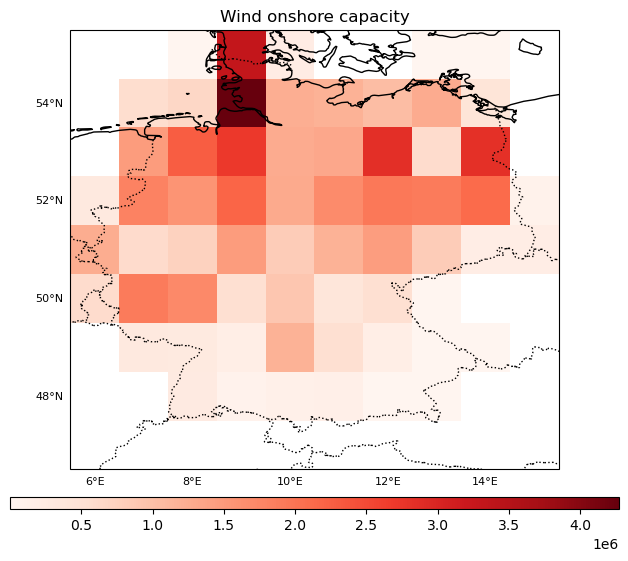

In [20]:
lon_edges = grid.lon.values #- (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values #- (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_on_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = MultipleLocator(2)
gl.ylocator = MultipleLocator(2)
ax.set_title('Wind onshore capacity')

plt.tight_layout()
plt.show()

## Hub Height calculation

In [21]:
# Create a grid
grid_height = grid_func.create_ref_grid('wind_on_hub_height')
# grid_height

### Calculate weighted mean (Based upon the Bruttoleistung)

In [22]:
# Drop data without height values
gdf_2 = merged_df.dropna(subset=['Nabenhoehe'])
gdf_2

,Postleitzahl,Bruttoleistung,Nettonennleistung,Nabenhoehe,Rotordurchmesser,geometry,x,y,lat_idx,lon_idx
0,01454,6400.0,6400.0,73.000000,54.800000,POINT (13.91345 51.14013),13.913446,51.140132,4,8
1,01561,1.0,1.0,7.200000,2.700000,POINT (13.63389 51.29631),13.633891,51.296306,4,8
2,01594,37400.0,37400.0,135.145455,119.454545,POINT (13.29018 51.25891),13.290177,51.258906,4,7
3,01609,40900.0,40900.0,124.687500,101.750000,POINT (13.42529 51.39129),13.425295,51.391292,4,7
4,01612,19100.0,19100.0,148.876000,126.000000,POINT (13.4084 51.29573),13.408405,51.295729,4,7
...,...,...,...,...,...,...,...,...,...,...
2768,99955,83150.0,83150.0,128.225806,107.000000,POINT (10.83291 51.16642),10.832915,51.166422,4,5
2769,99958,36000.0,36000.0,100.000000,80.545455,POINT (10.75165 51.09204),10.751649,51.092040,4,5
2770,99976,16519.6,16519.6,78.375000,50.281250,POINT (10.33357 51.25391),10.333567,51.253907,4,4
2771,99988,600.0,600.0,46.000000,43.000000,POINT (10.26928 51.17095),10.269281,51.170951,4,4


In [23]:
# Check if there are any cells that don't have a height value
no_height = merged_df[merged_df['Nabenhoehe'].isna()] # Entries without height values
coords_pairs_used = list(set(zip(gdf_2['lat_idx'], gdf_2['lon_idx']))) # All lat/lon pairs that have a some wind data value
no_height['lat_lon'] = list(zip(no_height['lat_idx'], no_height['lon_idx']))
no_height_subset = no_height[~no_height['lat_lon'].isin(coords_pairs_used)] # Check which lat/lon pairs don't have a height value
no_height_subset['lat_lon']


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


252    (3, 7)
Name: lat_lon, dtype: object

In [24]:
grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))
grid_mean_height_weighted

/tmp/ipykernel_3708539/3234131996.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))


lat_idx  lon_idx
1        2          123.445581
         3          130.955418
         4          102.837065
         5          136.906749
         6          105.118009
                       ...    
8        2           34.750000
         3           84.642651
         4           83.784435
         7           45.537500
         8           40.000000
Length: 62, dtype: float64

In [30]:
# Add the hieght value of the neighbouring cell for the one cell with no height value
grid_mean_height_weighted.loc[(3, 7)] = grid_mean_height_weighted.loc[(3, 6)]

In [31]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_mean_height_weighted.items():
    grid_height[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid_height)

In [32]:
# Save grid as raster file
grid_height.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')

In [33]:
# Open File
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
# grid

In [34]:
grid

<xarray.Dataset> Size: 904B
Dimensions:             (lat: 9, lon: 10)
Coordinates:
  * lat                 (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon                 (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs                 int64 8B ...
    gridtype            <U6 24B ...
Data variables:
    wind_on_hub_height  (lat, lon) float64 720B ...

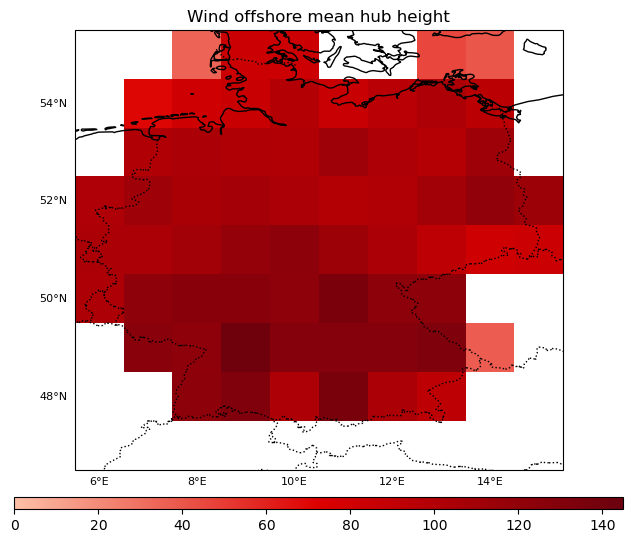

In [ ]:
lon_edges = grid.lon.values
lat_edges = grid.lat.values

# Plot the data
min_val = 0 # 30 # grid['wind_off_hub_height'].min().values = 34.75
max_val = 145 # grid['wind_off_hub_height'].max().values = 141.76

colors = ['#fcbfa6', '#dd0000', '#6b010e']# ['#ff9999', '#cc0000', '#4d0000']  # light red to dark red
custom_cmap = LinearSegmentedColormap.from_list("custom_red", colors)

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_on_hub_height'], transform=ccrs.PlateCarree(), cmap=custom_cmap, vmin=min_val, vmax=max_val)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = MultipleLocator(2)
gl.ylocator = MultipleLocator(2)
ax.set_title('Wind offshore mean hub height')

plt.tight_layout()
plt.show()